# Modelado con K-Fold Cross Validation y Ajuste de Hiperparámetros

Este notebook implementa las mejores prácticas para la evaluación de modelos de Machine Learning utilizando **K-Fold Cross Validation** (CV). El objetivo es encontrar la configuración óptima para cada modelo y obtener una estimación robusta de su desempeño antes de probar con los datos finales de prueba.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, make_scorer
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings("ignore")

In [40]:
# Cargar los datos procesados con PCA
X_train = np.load('X_train_pca.npy')
X_test = np.load('X_test_pca.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

print("Datos cargados exitosamente.")
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba (Hold-out): {X_test.shape}")

Datos cargados exitosamente.
Entrenamiento: (540, 3)
Prueba (Hold-out): (135, 3)


---
## 1. Configuración de la Estrategia de Validación

Definimos el objeto `StratifiedKFold` en un bloque separado. Esto asegura que todos los modelos que evaluemos a continuación sean probados sobre las **mismas particiones de datos**, permitiendo una comparación científica y justa.

In [41]:

# Utilizamos Stratified para mantener el balance de clases (65% Benigno / 35% Maligno) en cada fold.
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Estrategia configurada: {cv_strategy.n_splits} Folds Estratificados.")

Estrategia configurada: 10 Folds Estratificados.


In [42]:
# Definir scorer con pos_label=4 (Maligno) para evitar warnings
# sklearn por defecto asume pos_label=1, pero nuestras etiquetas son {2, 4}
scoring_maligno = make_scorer(f1_score, pos_label=4)
print("Scorer definido: F1 con pos_label=4 (Maligno)")

Scorer definido: F1 con pos_label=4 (Maligno)


---
## 2. Ajuste de Hiperparámetros (Grid Search)

Utilizaremos `GridSearchCV` para encontrar los mejores parámetros. Optimizaremos para la métrica **F1-Score** (o Recall) para asegurar que el modelo sea sensible a la detección de tumores malignos.

In [43]:
print("Sintonizando SVM...")
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(SVC(probability=True, class_weight='balanced'), 
                        param_grid_svm, 
                        cv=cv_strategy, 
                        scoring=scoring_maligno, 
                        verbose=1)
grid_svm.fit(X_train, y_train)

print(f"Mejores parámetros SVM: {grid_svm.best_params_}")
print(f"Mejor F1-Score (CV): {grid_svm.best_score_:.4f}")

Sintonizando SVM...
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Mejores parámetros SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor F1-Score (CV): 0.9716


In [44]:
print("\nSintonizando Regresión Logística...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'), 
                       param_grid_lr, 
                       cv=cv_strategy, 
                       scoring=scoring_maligno, 
                       verbose=1)
grid_lr.fit(X_train, y_train)

print(f"Mejores parámetros LR: {grid_lr.best_params_}")
print(f"Mejor F1-Score (CV): {grid_lr.best_score_:.4f}")


Sintonizando Regresión Logística...
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Mejores parámetros LR: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor F1-Score (CV): 0.9711


In [ ]:
print("\nSintonizando Random Forest...")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                       param_grid_rf, 
                       cv=cv_strategy, 
                       scoring=scoring_maligno, 
                       verbose=1)
grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor F1-Score (CV): {grid_rf.best_score_:.4f}")


Sintonizando Random Forest...
Fitting 10 folds for each of 24 candidates, totalling 240 fits


---
## 3. Evaluación Final en el Conjunto de Prueba (Unseen Data)

Seleccionamos el mejor estimador basado en los resultados de Cross-Validation y lo validamos con el conjunto `X_test` que no fue utilizado en ninguna parte del proceso de sintonización.

Reporte de Clasificación Final (Sobre Test Set)
---------------------------------------------
              precision    recall  f1-score   support

     Benigno       0.99      0.93      0.96        88
     Maligno       0.88      0.98      0.93        47

    accuracy                           0.95       135
   macro avg       0.94      0.96      0.94       135
weighted avg       0.95      0.95      0.95       135



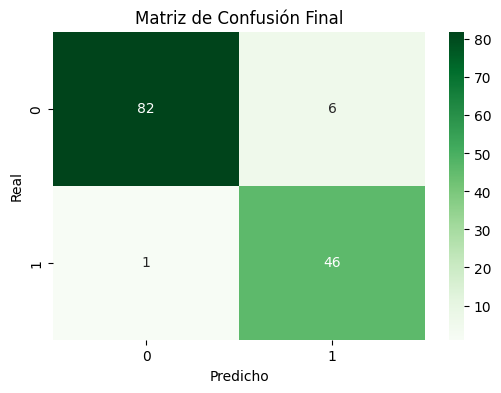

In [ ]:
best_model = grid_svm.best_estimator_

y_pred = best_model.predict(X_test)
print("Reporte de Clasificación Final (Sobre Test Set)")
print("-"*45)
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno']))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión Final')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

---
## 3. Comparación Formal de Modelos

Evaluamos los tres modelos optimizados sobre el conjunto de prueba (hold-out) y comparamos métricas clave: F1-Score, Recall de la clase Maligna, Accuracy y AUC-ROC. La métrica principal es el **Recall de la clase Maligna**, ya que un falso negativo (tumor maligno no detectado) tiene consecuencias clínicas más graves que una falsa alarma.

In [ ]:
from sklearn.metrics import recall_score, precision_score, accuracy_score

# --- Recopilar predicciones de los 3 mejores modelos ---
modelos = {
    "SVM (RBF)": grid_svm.best_estimator_,
    "Reg. Logística": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
}

resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]  # P(Maligno)
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (Maligno)": f1_score(y_test, y_pred, pos_label=4),
        "Recall (Maligno)": recall_score(y_test, y_pred, pos_label=4),
        "Precisión (Maligno)": precision_score(y_test, y_pred, pos_label=4),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        "F1-Score CV (train)": grid_svm.best_score_ if nombre == "SVM (RBF)"
                               else grid_lr.best_score_ if nombre == "Reg. Logística"
                               else grid_rf.best_score_,
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print("Comparación Formal de Modelos")
print(df_resultados.round(4).to_string())

Comparación Formal de Modelos
                Accuracy  F1 (Maligno)  Recall (Maligno)  Precisión (Maligno)  AUC-ROC  F1-Score CV (train)
Modelo                                                                                                     
SVM (RBF)         0.9481        0.9293            0.9787               0.8846   0.9853               0.9716
Reg. Logística    0.9333        0.9072            0.9362               0.8800   0.9850               0.9711
Random Forest     0.9481        0.9293            0.9787               0.8846   0.9845               0.9666


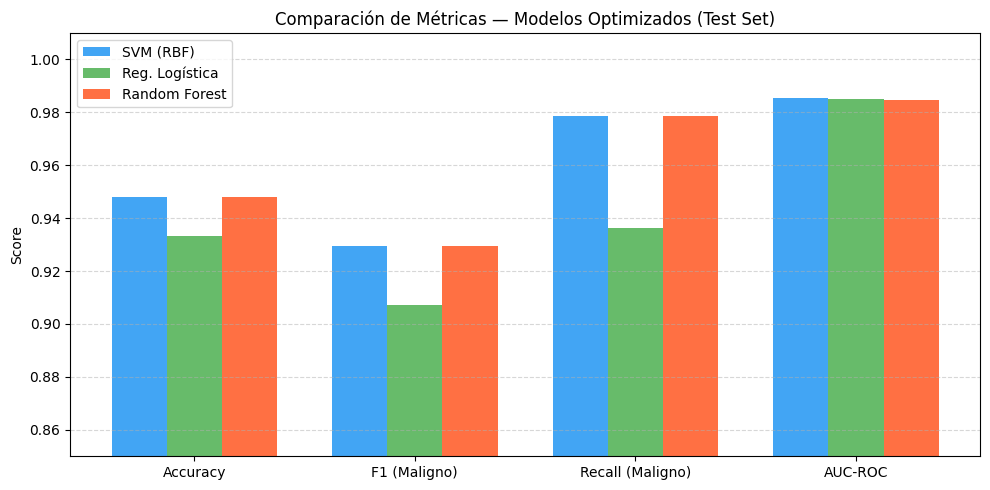

In [ ]:
# --- Gráfica de barras comparativa ---
metricas = ["Accuracy", "F1 (Maligno)", "Recall (Maligno)", "AUC-ROC"]
x = np.arange(len(metricas))
width = 0.25
colores = ["#2196F3", "#4CAF50", "#FF5722"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    vals = [row[m] for m in metricas]
    ax.bar(x + i*width, vals, width, label=nombre, color=colores[i], alpha=0.85)

ax.set_ylim(0.85, 1.01)
ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylabel("Score")
ax.set_title("Comparación de Métricas — Modelos Optimizados (Test Set)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 4. Análisis de Overfitting vs Underfitting (Curvas de Aprendizaje)

Las curvas de aprendizaje muestran cómo evoluciona el desempeño del modelo (en entrenamiento y validación) conforme aumenta el tamaño del conjunto de entrenamiento. Permiten diagnosticar:

- **Underfitting (alto sesgo):** el modelo no aprende bien ni en train ni en validación → ambas curvas convergen en un valor bajo.
- **Overfitting (alta varianza):** el modelo aprende demasiado el train pero falla en validación → brecha grande entre ambas curvas.
- **Ajuste correcto:** las curvas convergen y se estabilizan en un valor alto con una brecha mínima.

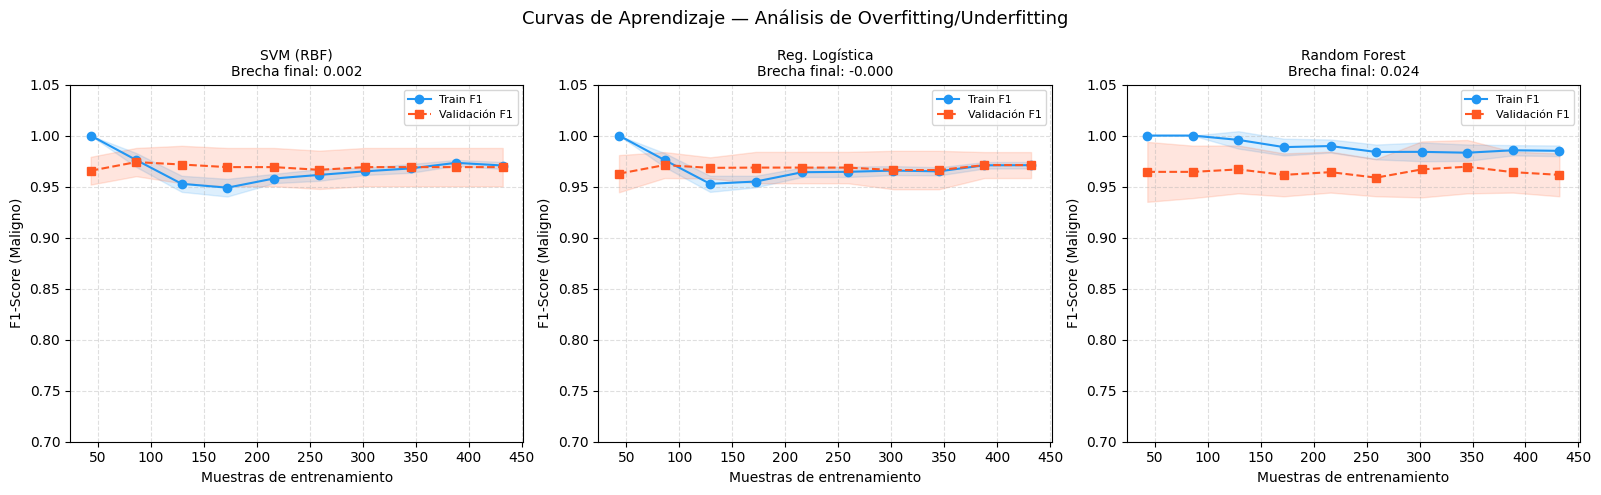

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Curvas de Aprendizaje — Análisis de Overfitting/Underfitting", fontsize=13)

modelos_lc = [
    ("SVM (RBF)", grid_svm.best_estimator_),
    ("Reg. Logística", grid_lr.best_estimator_),
    ("Random Forest", grid_rf.best_estimator_),
]

for ax, (nombre, modelo) in zip(axes, modelos_lc):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring_maligno,
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", color="#2196F3", label="Train F1")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#2196F3")
    ax.plot(train_sizes, val_mean, "s--", color="#FF5722", label="Validación F1")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#FF5722")

    gap = train_mean[-1] - val_mean[-1]
    ax.set_title(f"{nombre}\nBrecha final: {gap:.3f}", fontsize=10)
    ax.set_xlabel("Muestras de entrenamiento")
    ax.set_ylabel("F1-Score (Maligno)")
    ax.set_ylim(0.70, 1.05)
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# --- Diagnóstico numérico: brecha train vs. validación ---
print("Diagnóstico de Sesgo/Varianza (brecha Train - Val en el 100% de los datos)\n")
print(f'{"Modelo":<20} {"F1-Train":>10} {"F1-Val (CV)":>12} {"Brecha":>8} {"Diagnóstico":>15}')
print("-"*70)

for nombre, modelo in modelos_lc:
    _, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train,
        train_sizes=[1.0],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring_maligno,
        n_jobs=-1
    )
    t = train_scores.mean()
    v = val_scores.mean()
    gap = t - v
    if v < 0.80:
        diag = "Underfitting"
    elif gap > 0.10:
        diag = "Overfitting"
    else:
        diag = "Ajuste correcto"
    print(f"{nombre:<20} {t:>10.4f} {v:>12.4f} {gap:>8.4f} {diag:>15}")

Diagnóstico de Sesgo/Varianza (brecha Train - Val en el 100% de los datos)

Modelo                 F1-Train  F1-Val (CV)   Brecha     Diagnóstico
----------------------------------------------------------------------
SVM (RBF)                0.9707       0.9691   0.0016 Ajuste correcto
Reg. Logística           0.9710       0.9711  -0.0001 Ajuste correcto
Random Forest            0.9850       0.9615   0.0235 Ajuste correcto
